In [ ]:
We'll Do Data Cleaning Here

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load data
df = pd.read_csv('../data/churn.csv')

# Quick inspection
print(df.shape)
print(df.info())
print(df.head())
print(df.isnull().sum())  # Should be zero - dataset is clean

(10000, 14)
<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  str    
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  str    
 5   Gender           10000 non-null  str    
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), str(3)
memory usage: 1.1 MB
None
   RowNumber  CustomerId   Surname  CreditScore Geography  Gender  Age  \
0          1    15

In [5]:
df_clean = df.copy()  # Create a copy for cleaning

df_clean = df_clean.drop(['RowNumber', 'CustomerId', 'Surname'], axis=1)  # Drop unnecessary columns

print(f"Duplicates: {df_clean.duplicated().sum()}")  # Check for duplicates

df_clean['AgeGroup']=pd.cut(df_clean['Age'], bins=[0, 30, 40, 50, 60, 100], labels=['18-30', '31-40', '41-50', '51-60', '60+'])

df_clean['BalanceCategory'] = pd.cut(df_clean['Balance'], bins=[-1, 0, 10000, 50000, 100000, np.inf], labels=['Zero', 'Low', 'Medium', 'High', 'Very High'])

df_clean['TenureGroup'] = pd.cut(df_clean['Tenure'], bins=[-1, 2, 5, 10], labels=['New(<2 yrs)', 'Medium (2-5 yrs)', 'Long (>5 yrs)'])



Duplicates: 0


In [6]:
df_clean.head(5)

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,AgeGroup,BalanceCategory,TenureGroup
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1,41-50,Zero,New(<2 yrs)
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0,41-50,High,New(<2 yrs)
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1,41-50,Very High,Long (>5 yrs)
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0,31-40,Zero,New(<2 yrs)
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0,41-50,Very High,New(<2 yrs)


This Part Includes all the analysis regarding the churns

In [ ]:
churn_rate = df_clean['Exited'].mean() * 100
print(f"Overall Churn Rate: {churn_rate:.2f}%")

churn_by_geo = df_clean.groupby('Geography')['Exited'].agg(['mean', 'count']) 
churn_by_geo['churn_ rate'] = churn_by_geo['mean']*100
print(churn_by_geo.sort_values('churn_ rate', ascending=False))

churn_by_age = df_clean.groupby('AgeGroup')['Exited'].agg(['mean'])
churn_by_age['churn_rate'] = churn_by_age['mean']*100
print(churn_by_age.sort_values('churn_rate', ascending=False))

active_churn = df_clean.groupby('IsActiveMember')['Exited'].agg(['mean', 'count'])
active_churn['churn_rate'] = active_churn['mean']*100
print(active_churn.sort_values('churn_rate', ascending=False))

churn_by_tenure = df_clean.groupby('TenureGroup')['Exited'].agg(['mean', 'count'])
churn_by_tenure['churn_rate'] = churn_by_tenure['mean']*100
print(churn_by_tenure.sort_values('churn_rate', ascending=False))


Overall Churn Rate: 20.37%
               mean  count  churn_ rate
Geography                              
Germany    0.324432   2509    32.443204
Spain      0.166734   2477    16.673395
France     0.161548   5014    16.154767
              mean  churn_rate
AgeGroup                      
51-60     0.562108   56.210790
41-50     0.339655   33.965517
60+       0.247845   24.784483
31-40     0.120872   12.087171
18-30     0.075203    7.520325
                    mean  count  churn_rate
IsActiveMember                             
0               0.268509   4849   26.850897
1               0.142691   5151   14.269074
                      mean  count  churn_rate
TenureGroup                                  
New(<2 yrs)       0.211538   2496   21.153846
Medium (2-5 yrs)  0.207641   3010   20.764120
Long (>5 yrs)     0.196707   4494   19.670672


Now lets Work on Visualisation

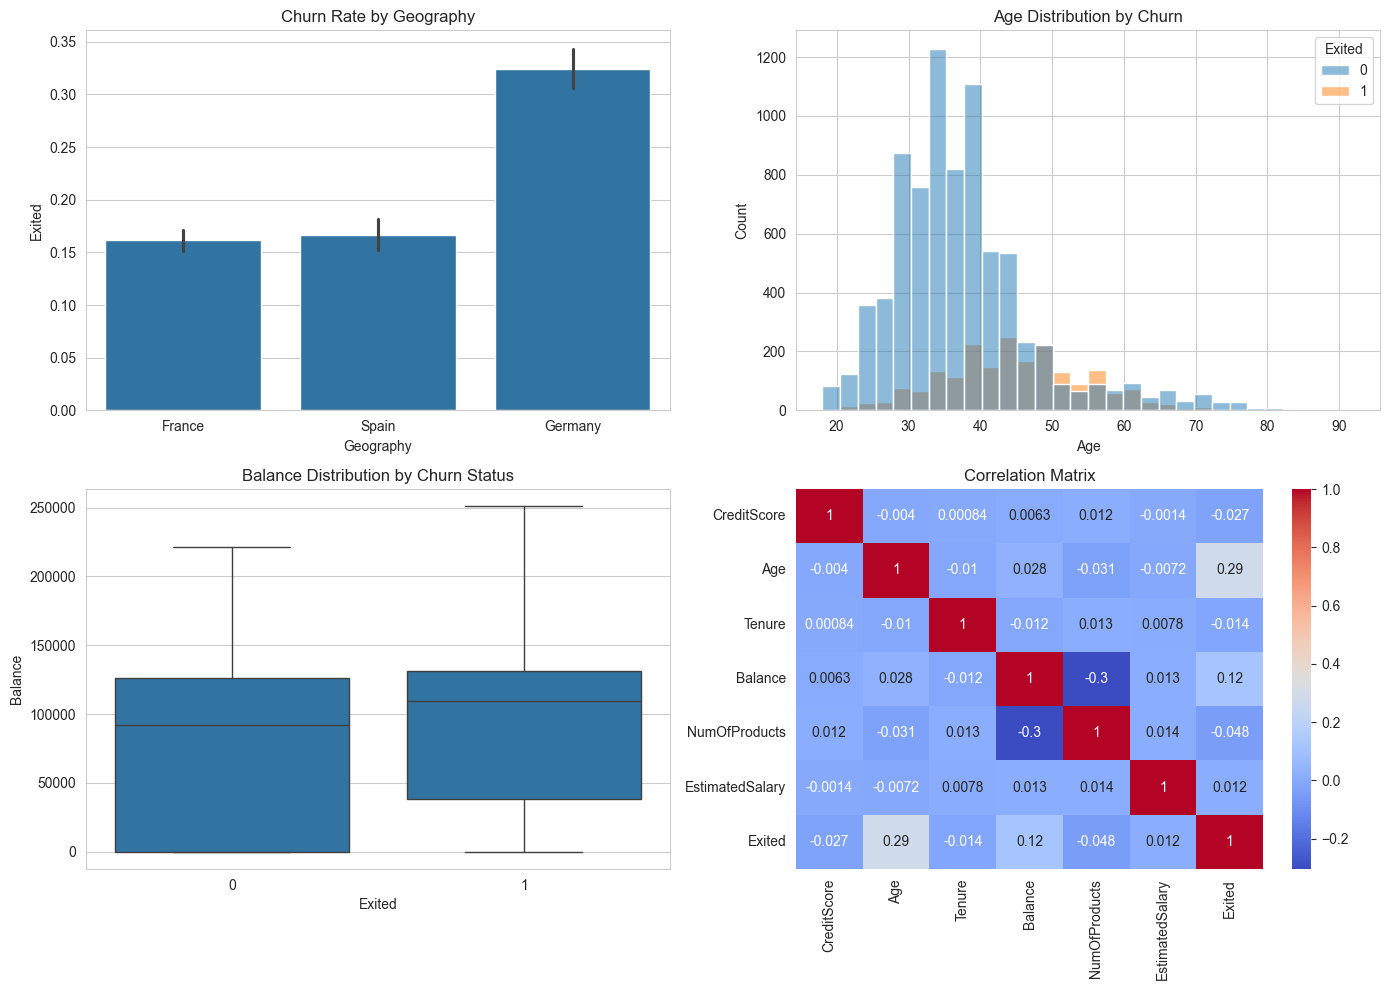

In [13]:
sns.set_style('whitegrid')

fig, axes = plt.subplots(2,2, figsize=(14,10))

sns.barplot(data=df_clean, x="Geography", y="Exited", ax=axes[0,0])
axes[0,0].set_title('Churn Rate by Geography')
axes[0,1].set_title('Churn Rate')

sns.histplot(data=df_clean, x="Age", hue="Exited", bins=30, ax=axes[0,1])
axes[0,1].set_title('Age Distribution by Churn')

sns.boxplot(data=df_clean, x='Exited', y='Balance', ax=axes[1,0])
axes[1,0].set_title('Balance Distribution by Churn Status')

# Plot 4: Correlation heatmap
numeric_cols = ['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 
                'EstimatedSalary', 'Exited']
corr = df_clean[numeric_cols].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', ax=axes[1,1])
axes[1,1].set_title('Correlation Matrix')

plt.tight_layout()
plt.savefig('../visualizations/eda_plots.png')

Preparing Model For Training 

In [ ]:

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

# Encode categorical variables
le_geo = LabelEncoder()
le_gender = LabelEncoder()

df_model = df_clean.copy()
df_model['Geography'] = le_geo.fit_transform(df_model['Geography'])
df_model['Gender'] = le_gender.fit_transform(df_model['Gender'])

# Select features for modeling
features = ['CreditScore', 'Geography', 'Gender', 'Age', 'Tenure', 
            'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 
            'EstimatedSalary']
X = df_model[features]
y = df_model['Exited']

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, 
                                                    test_size=0.2, 
                                                    random_state=42)

Training Model

In [ ]:
# Train model
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# Predictions
y_pred = rf_model.predict(X_test)
y_pred_proba = rf_model.predict_proba(X_test)[:, 1]

# Evaluation
print(classification_report(y_test, y_pred))
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_pred_proba):.3f}")

# Feature importance - THIS IS GOLD for business stakeholders
feature_importance = pd.DataFrame({
    'feature': features,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False)

print("\nTop 5 Churn Drivers:")
print(feature_importance.head())